[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Instance Segmentation on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
# Monta o Google Drive no caminho padrão /content/gdrive
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
!nvidia-smi

Sat Dec 20 06:57:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
!pip install roboflow

from roboflow import Roboflow

api_key = userdata.get("ROBOFLOW_API_KEY")
if not api_key:
    raise ValueError("Missing ROBOFLOW_API_KEY in Colab userdata")

rf = Roboflow(api_key=api_key)
project = rf.workspace("zebrarecog").project("zebrafish-detection-2-flcpc")
version = project.version(5)
dataset = version.download("yolov11")

Diretório HOME definido como: /content/gdrive/MyDrive/YOLO11_IS
Diretório de trabalho atual: /content/gdrive/MyDrive/YOLO11_IS


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 43.0/235.7 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [ ]:
!yolo task=segment mode=predict model=yolo11l-seg.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
YOLO11l-seg summary (fused): 491 layers, 27,646,272 parameters, 0 gradients, 132.2 GFLOPs

Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
image 1/1 /content/gdrive/MyDrive/YOLO11_IS/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 1 backpack, 94.7ms
Speed: 5.2ms preprocess, 94.7ms inference, 91.9ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/segment/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

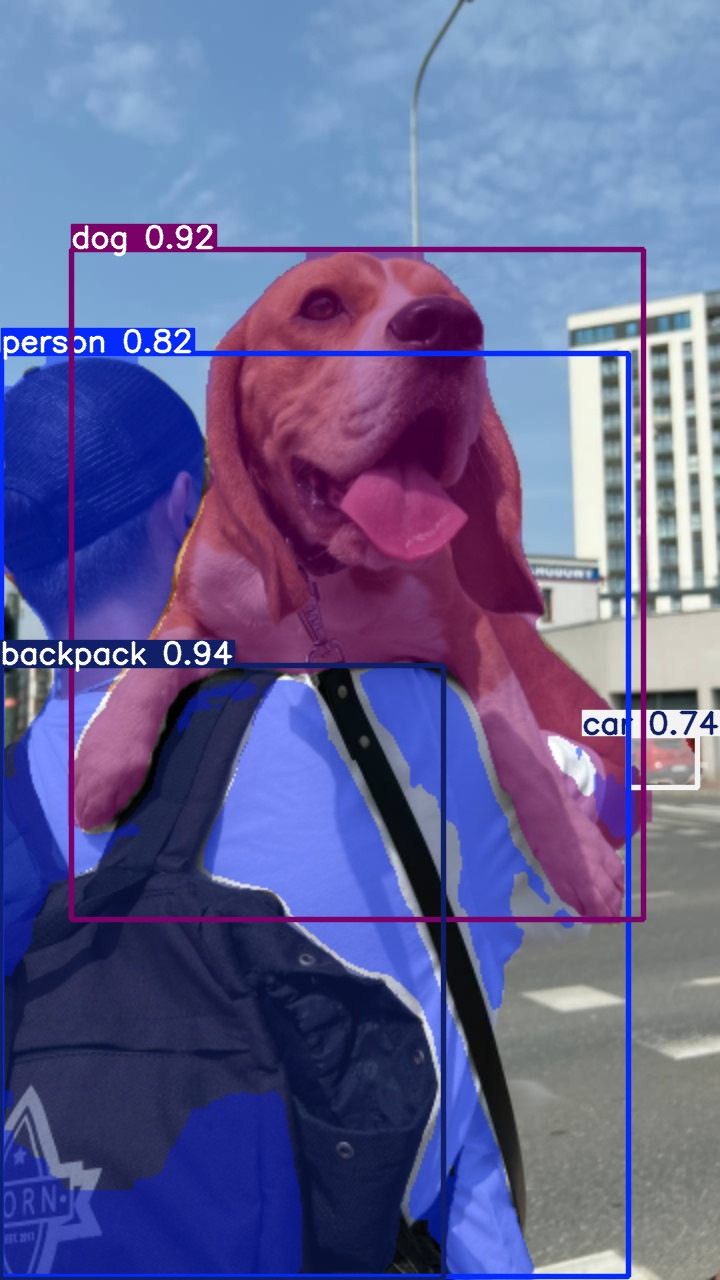

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/segment/predict/dog.jpg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11l-seg.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 1 person, 1 car, 1 dog, 1 backpack, 100.0ms
Speed: 6.3ms preprocess, 100.0ms inference, 88.0ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [ ]:
result.boxes.xyxy

tensor([[0.0000e+00, 6.6551e+02, 4.4326e+02, 1.2796e+03],
        [7.1099e+01, 2.4921e+02, 6.4364e+02, 9.1945e+02],
        [1.1769e+00, 3.5331e+02, 6.2886e+02, 1.2768e+03],
        [6.2872e+02, 7.3547e+02, 6.9789e+02, 7.8725e+02]], device='cuda:0')

In [ ]:
result.boxes.conf

tensor([0.9364, 0.9157, 0.8150, 0.7366], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([24., 16.,  0.,  2.], device='cuda:0')

In [ ]:
result.masks.data

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

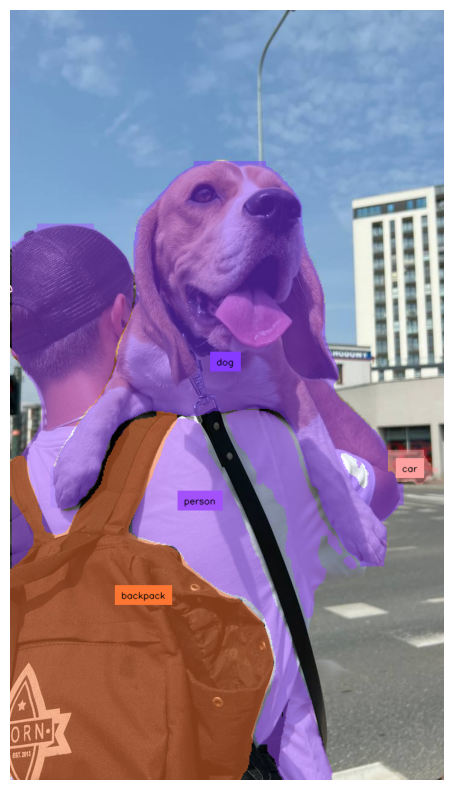

In [ ]:
mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK, text_position=sv.Position.CENTER)

annotated_image = image.copy()
annotated_image = mask_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/ks-fsm9o/pelvis-ap-x-ray) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="WUbbaZaYIIDCdQf1Fl4F")
project = rf.workspace("zebrarecog").project("zebrafish-detection-2-flcpc")
version = project.version(5)
dataset = version.download("yolov11")

mkdir: cannot create directory ‘/content/gdrive/MyDrive/YOLO11_IS/datasets’: File exists
/content/gdrive/MyDrive/YOLO11_IS/datasets
loading Roboflow workspace...
loading Roboflow project...


## Custom Training

In [ ]:
import os
import glob

# Remove arquivos de cache para forçar re-escaneamento
for cache_file in glob.glob(f"{dataset.location}/**/labels.cache", recursive=True):
    os.remove(cache_file)
    print(f"Cache deletado: {cache_file}")

Cache deletado: /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/train/labels.cache
Cache deletado: /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/valid/labels.cache


In [ ]:
import os
import glob
from tqdm import tqdm # Barra de progresso para vc não achar que travou

DATASET_PATH = dataset.location # O caminho do Roboflow

def sanitize_dataset(split='train'):
    labels_path = os.path.join(DATASET_PATH, split, 'labels')
    images_path = os.path.join(DATASET_PATH, split, 'images')

    if not os.path.exists(labels_path):
        print(f"Pasta não encontrada: {labels_path}")
        return

    print(f"Varrendo inconsistências em: {split}...")

    files = glob.glob(os.path.join(labels_path, "*.txt"))
    bad_files = []

    # Barra de progresso pq são 47k arquivos
    for file_path in tqdm(files):
        with open(file_path, 'r') as f:
            lines = f.readlines()

        is_corrupt = False
        # Se o arquivo estiver vazio, tudo bem (background image).
        # O problema é ter linha com 5 números (formato YOLO Detect)
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5: # Classe + 4 coords = CAIXA (Erro para Seg)
                is_corrupt = True
                break

        if is_corrupt:
            bad_files.append(file_path)

    if bad_files:
        print(f"\n🚨 Encontrados {len(bad_files)} arquivos de DETECÇÃO (errados) em {split}.")
        print("Removendo arquivos problemáticos...")

        count = 0
        for txt_file in bad_files:
            try:
                os.remove(txt_file)
                # Tenta remover a imagem par para não deixar lixo
                img_jpg = txt_file.replace('labels', 'images').replace('.txt', '.jpg')
                if os.path.exists(img_jpg): os.remove(img_jpg)
                count += 1
            except OSError as e:
                print(f"Erro ao deletar {txt_file}: {e}")
        print(f"✅ Limpeza concluída em {split}. {count} pares removidos.")
    else:
        print(f"✅ Pasta {split} está limpa! Nenhum arquivo de detecção encontrado.")

# Executa para treino e validação
sanitize_dataset('train')
sanitize_dataset('valid')
# sanitize_dataset('test') # Se existir

Varrendo inconsistências em: train...


100%|██████████| 48958/48958 [02:31<00:00, 322.59it/s]



🚨 Encontrados 283 arquivos de DETECÇÃO (errados) em train.
Removendo arquivos problemáticos...
✅ Limpeza concluída em train. 283 pares removidos.
Varrendo inconsistências em: valid...


100%|██████████| 2003/2003 [00:05<00:00, 396.73it/s]



🚨 Encontrados 13 arquivos de DETECÇÃO (errados) em valid.
Removendo arquivos problemáticos...
✅ Limpeza concluída em valid. 13 pares removidos.


In [ ]:
!yolo task=segment mode=train \
model=yolo11s-seg.pt \
data={dataset.location}/data.yaml \
epochs=130 \
imgsz=640 \
batch=128 \
patience=50 \
project='{HOME}/runs' \
name='treino_IS' \
save=True \
cache=True \
workers=16 \
device=0 \
plots=True \
cos_lr=True  # Adiciona suavização na taxa de aprendizado final

New https://pypi.org/project/ultralytics/8.3.240 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: task=segment, mode=train, model=yolo11s-seg.pt, data=/content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/data.yaml, epochs=130, time=None, patience=50, batch=128, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=16, project=/content/gdrive/MyDrive/YOLO11_IS/runs, name=treino_IS2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, 

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/treino_IS2/

args.yaml					     results.png
BoxF1_curve.png					     train_batch0.jpg
BoxP_curve.png					     train_batch1.jpg
BoxPR_curve.png					     train_batch2.jpg
BoxR_curve.png					     train_batch45720.jpg
confusion_matrix_normalized.png			     train_batch45721.jpg
confusion_matrix.png				     train_batch45722.jpg
events.out.tfevents.1766169057.4f13a0e1fd3b.15457.0  val_batch0_labels.jpg
labels_correlogram.jpg				     val_batch0_pred.jpg
labels.jpg					     val_batch1_labels.jpg
MaskF1_curve.png				     val_batch1_pred.jpg
MaskP_curve.png					     val_batch2_labels.jpg
MaskPR_curve.png				     val_batch2_pred.jpg
MaskR_curve.png					     weights
results.csv


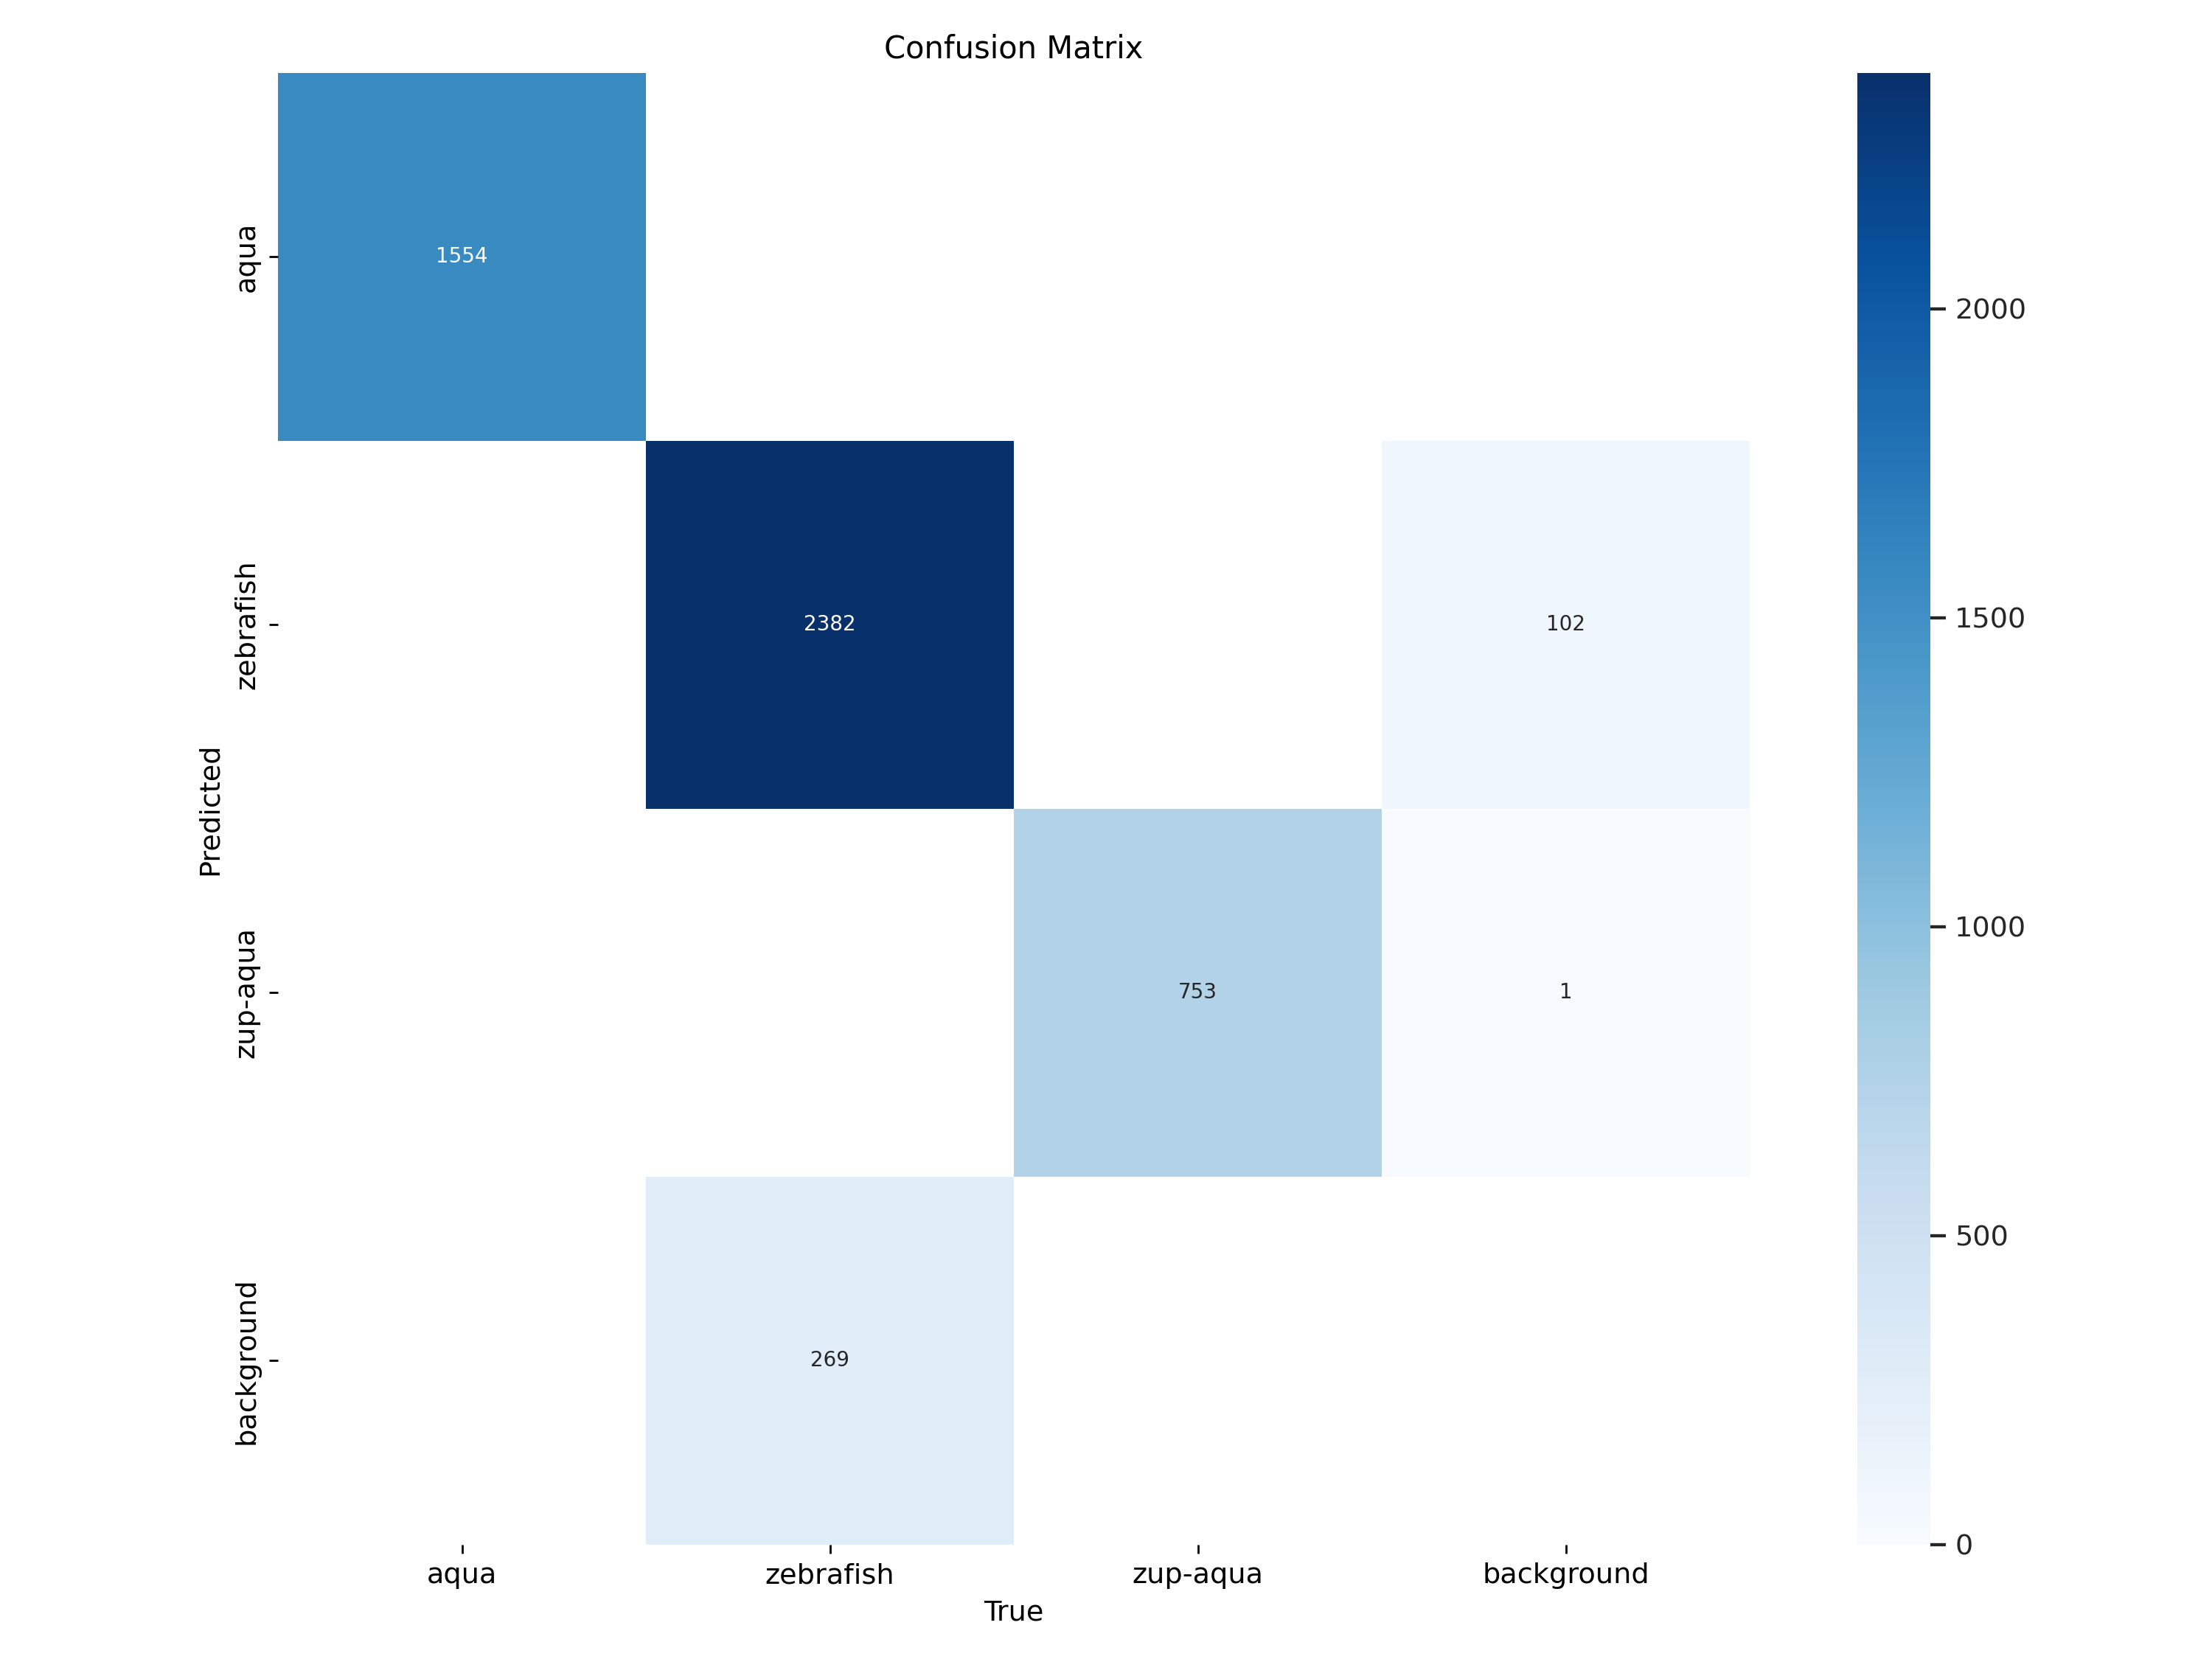

In [ ]:
from IPython.display import Image as IPyImage

# Ajustando o caminho para a pasta correta 'treino_IS2'
IPyImage(filename=f'{HOME}/runs/treino_IS2/confusion_matrix.png', width=600)

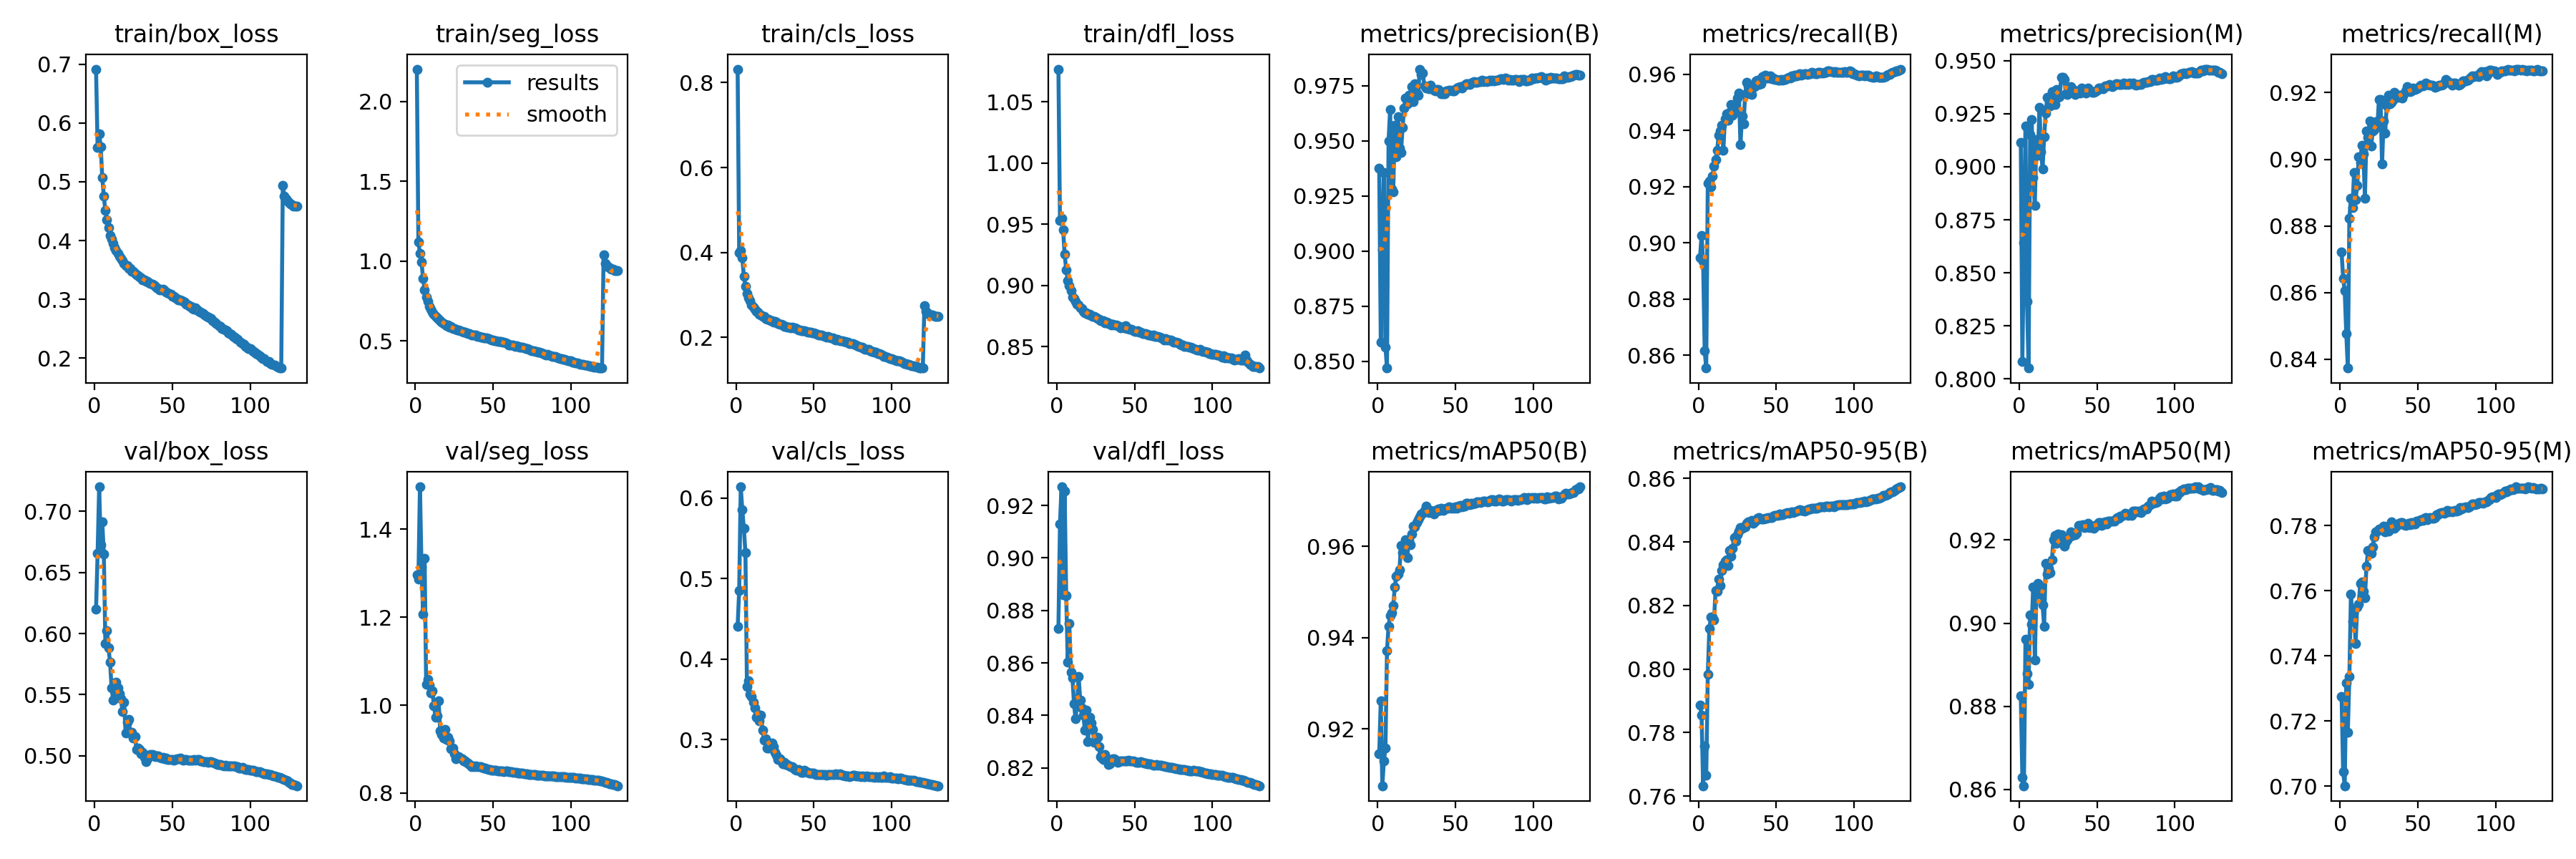

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/treino_IS2/results.png', width=600)

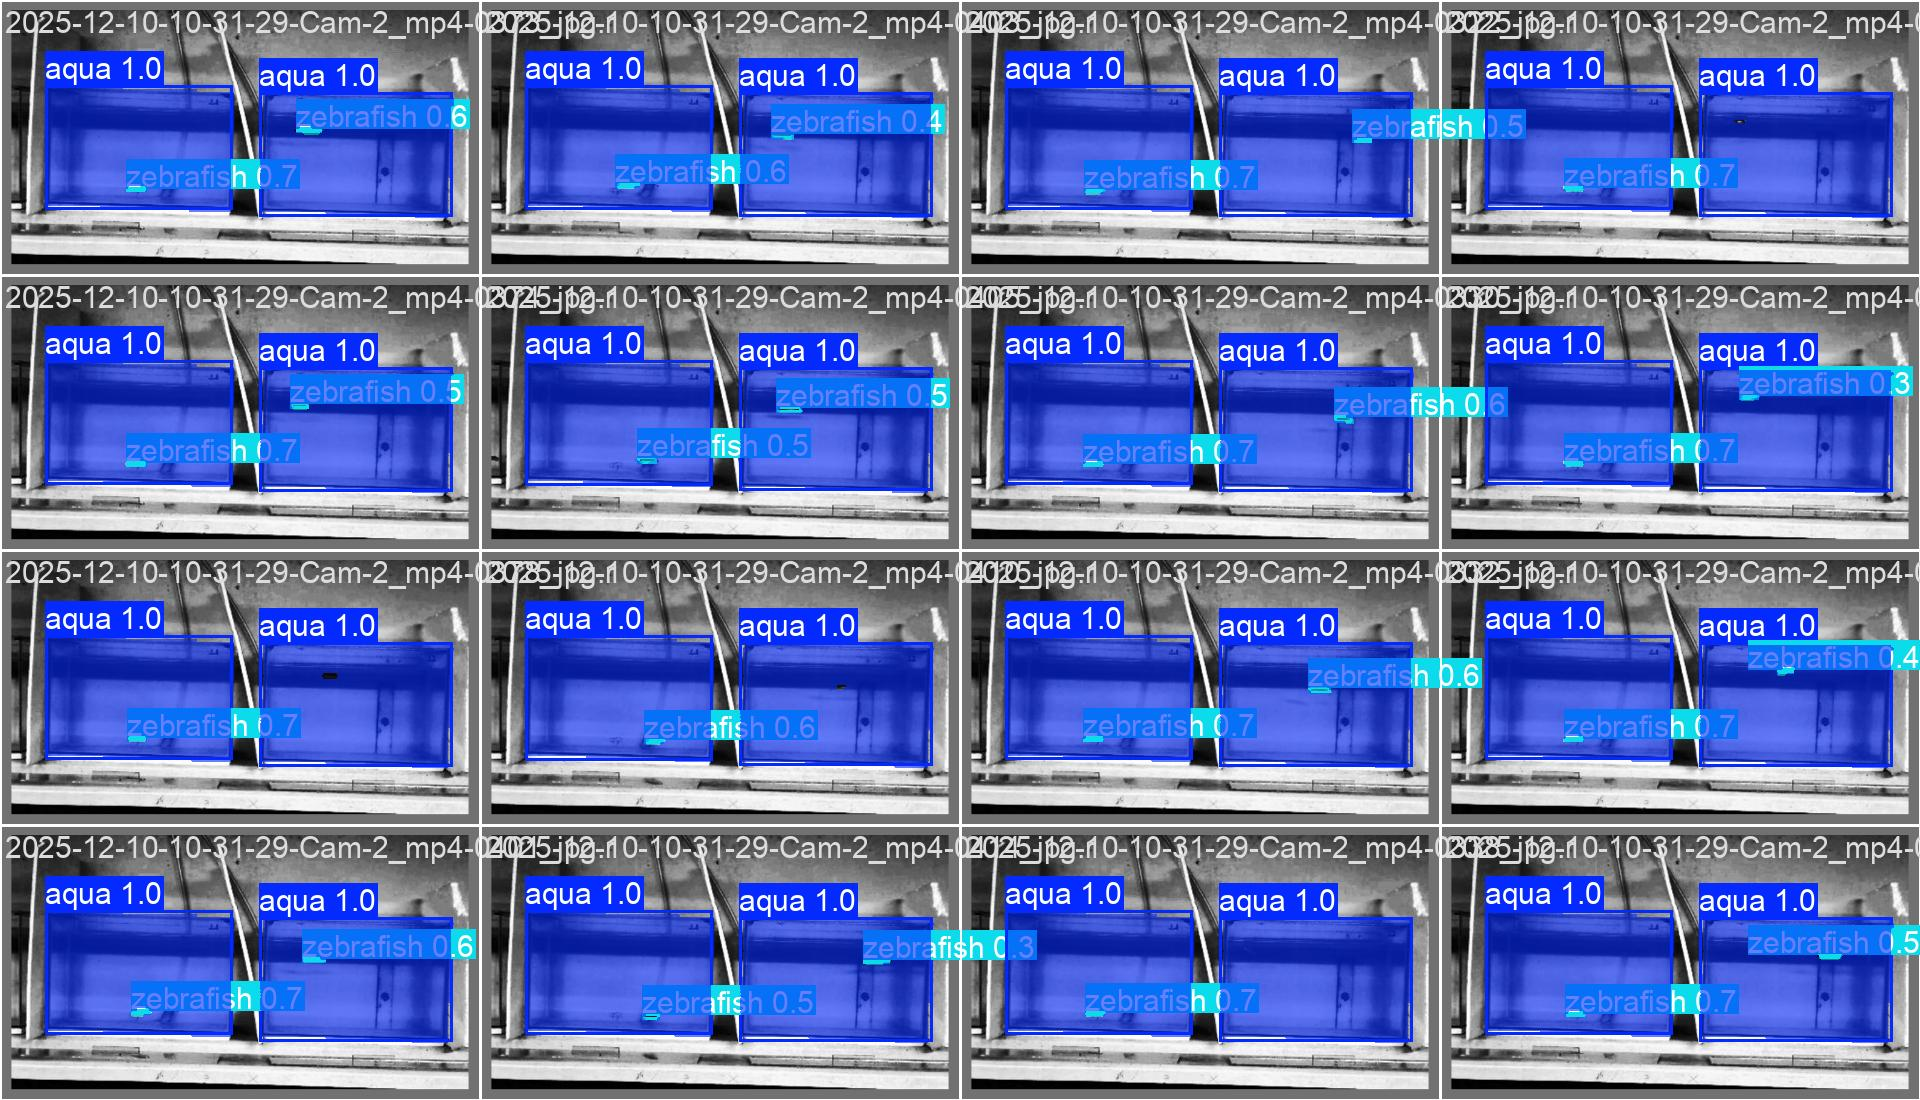

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/treino_IS2/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=segment mode=val \
model='{HOME}/runs/treino_IS2/weights/best.pt' \
data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
YOLO11s-seg summary (fused): 265 layers, 10,067,977 parameters, 0 gradients, 32.8 GFLOPs
val: Scanning /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/valid/labels.cache... 1990 images, 0 backgrounds, 0 corrupt: 100% 1990/1990 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% 125/125 [00:25<00:00,  4.82it/s]
                   all       1990       4958       0.98      0.962      0.973      0.857       0.94      0.923      0.926      0.786
                  aqua       1155       1554          1          1      0.995      0.995          1          1      0.995      0.995
             zebrafish       1980       2651      0.944      0.886      0.929      0.581      0.823      0.768      0.789      0.372
              zup-aqua        753        753      0.998          1     

## Inference with custom model

In [ ]:
!yolo task=segment mode=predict \
model='{HOME}/runs/treino_IS2/weights/best.pt' \
conf=0.25 \
source='{dataset.location}/test/images' \
save=True \
project='{HOME}/runs/predicoes_teste' \
name='teste_segmentacao'

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
YOLO11s-seg summary (fused): 265 layers, 10,067,977 parameters, 0 gradients, 32.8 GFLOPs

image 1/1000 /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images/00122-converted_mp4-0013_jpg.rf.77d7fd6a6886a34a0032d2cd67eb4fc3.jpg: 384x640 2 zebrafishs, 102.9ms
image 2/1000 /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images/00122-converted_mp4-0018_jpg.rf.4b9bcc7dcc03ea78d5496821776c3325.jpg: 384x640 2 zebrafishs, 11.2ms
image 3/1000 /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images/00122-converted_mp4-0019_jpg.rf.3e0fd0811cff903f3e30b04ae40bf33e.jpg: 384x640 4 zebrafishs, 11.0ms
image 4/1000 /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images/00122-converted_mp4-0026_jpg.rf.da742769a3aab4f739648064d355367c.jpg: 384x640 2 zebrafishs, 10.6ms
image 5/1000 /content/gdrive/MyDrive/YOLO11_IS/dat

**NOTE:** Let's take a look at few results.

📸 Visualizando resultados de: /content/gdrive/MyDrive/YOLO11_IS/runs/predicoes_teste/teste_segmentacao/



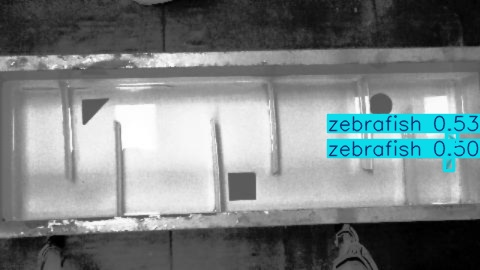

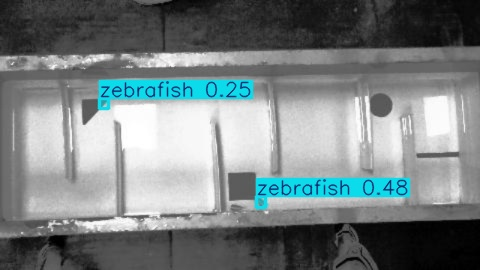

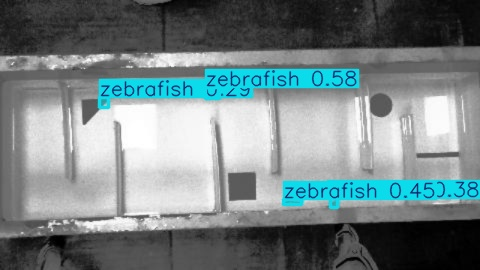

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

# 1. Definimos onde procurar (baseado no 'project' do comando anterior)
base_dir = f'{HOME}/runs/predicoes_teste'

try:
    # 2. Encontra a pasta mais recente dentro de predicoes_teste
    # (Isso pega 'teste_segmentacao', 'teste_segmentacao2', etc.)
    latest_folder = max(glob.glob(f'{base_dir}/*/'), key=os.path.getmtime)

    print(f"📸 Visualizando resultados de: {latest_folder}\n")

    # 3. Exibe as 3 primeiras imagens
    found_images = glob.glob(f'{latest_folder}/*.jpg')

    if not found_images:
        print("Nenhuma imagem .jpg encontrada nesta pasta.")

    for img in found_images[:3]:
        display(IPyImage(filename=img, width=600))
        print("\n")

except ValueError:
    print(f"❌ Nenhuma pasta encontrada em '{base_dir}'.")
    print("Verifique se o comando de 'predict' terminou de rodar ou se o caminho do projeto está correto.")

In [ ]:
!ls {HOME}/runs/predicoes_teste/teste_segmentacao

00122-converted_mp4-0013_jpg.rf.77d7fd6a6886a34a0032d2cd67eb4fc3.jpg
00122-converted_mp4-0018_jpg.rf.4b9bcc7dcc03ea78d5496821776c3325.jpg
00122-converted_mp4-0019_jpg.rf.3e0fd0811cff903f3e30b04ae40bf33e.jpg
00122-converted_mp4-0026_jpg.rf.da742769a3aab4f739648064d355367c.jpg
00123-converted_mp4-0004_jpg.rf.291522fdd3407be089c057825d814bc1.jpg
00123-converted_mp4-0013_jpg.rf.91ca855330f890bb6a85f4e48b11f7b4.jpg
00123-converted_mp4-0030_jpg.rf.3a17a31c63202976b34bef532088088b.jpg
00123-converted_mp4-0032_jpg.rf.d1423fd66c648c7d0611a1e2072ad84c.jpg
00416-seg01_frame_00001_jpg.rf.00cc76c0ca05eee21aa17890907002b2.jpg
00416-seg01_frame_00007_jpg.rf.1e751cb7744c36924446d788f9e43380.jpg
00416-seg03_frame_00007_jpg.rf.975f1cd18ba21f05f22a8bc3198c24f3.jpg
00416-seg04_frame_00005_jpg.rf.1916abf6324dc989b91a94db693464d5.jpg
00416-seg04_frame_00010_jpg.rf.6abbe6610d219b9773e0e90d4cb1ddbf.jpg
00416-seg04_frame_00014_jpg.rf.51af91dbe15d2aa9aaaea940833e078c.jpg
00416-seg05_frame_00013_jpg.rf.b4938fd99

📂 Lendo imagens de: /content/gdrive/MyDrive/YOLO11_IS/runs/predicoes_teste/teste_segmentacao/
🖼️ Exibindo: 00416-seg08_frame_00014_jpg.rf.ab4441d6f86e7ad793c66acb6f413d4b.jpg


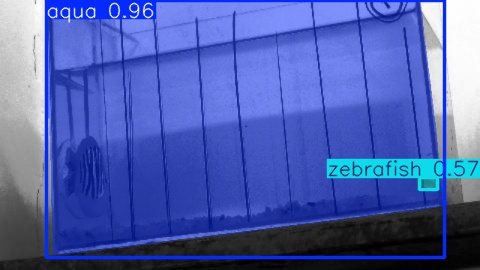

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

# 1. Ajuste do caminho: apontando para onde salvamos o teste personalizado
# Note o asterisco '*' no final para pegar qualquer pasta que comece com o nome (ex: teste_segmentacao, teste_segmentacao2)
search_path = f'{HOME}/runs/predicoes_teste/*/'

try:
    # 2. Pega a pasta mais recente dentro do seu projeto de testes
    latest_folder = max(glob.glob(search_path), key=os.path.getmtime)
    print(f"📂 Lendo imagens de: {latest_folder}")

    # 3. Busca os arquivos JPG
    # Adicionei 'sorted' para garantir que a ordem seja sempre a mesma (alfabética)
    all_images = sorted(glob.glob(f'{latest_folder}/*.jpg'))

    # 4. Seleciona especificamente a imagem de índice 17 (a 18ª imagem)
    # Verificação de segurança para não dar erro se tiver menos de 18 imagens
    if len(all_images) > 17:
        target_images = all_images[17:18]

        for img in target_images:
            print(f"🖼️ Exibindo: {os.path.basename(img)}")
            display(IPyImage(filename=img, width=600))
            print("\n")
    else:
        print(f"⚠️ A pasta contém apenas {len(all_images)} imagens. Não foi possível acessar o índice 17.")

except ValueError:
    print(f"❌ Nenhuma pasta encontrada em '{search_path}'. Verifique se o teste rodou corretamente.")

🎲 Arquivo selecionado aleatoriamente: WIN_20250818_17_04_29_Pro_frame_00251_jpg.rf.eea2aea8444658ad869f9916686c555d.jpg
📂 Caminho completo: /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images/WIN_20250818_17_04_29_Pro_frame_00251_jpg.rf.eea2aea8444658ad869f9916686c555d.jpg



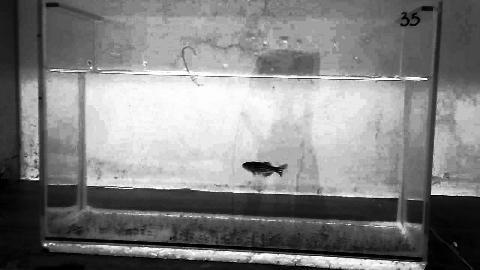

In [ ]:
import os
import glob
import random
from IPython.display import Image, display

# 1. Define a pasta alvo (Usei a do seu dataset de teste)
# Se quiser olhar as predições, troque por: f'{HOME}/runs/predicoes_teste/teste_segmentacao'
folder_path = f'{dataset.location}/test/images'

# 2. Lista todos os arquivos .jpg
files = glob.glob(f'{folder_path}/*.jpg')

if len(files) > 0:
    # 3. Sorteia um arquivo da lista
    chosen_file = random.choice(files)

    print(f"🎲 Arquivo selecionado aleatoriamente: {os.path.basename(chosen_file)}")
    print(f"📂 Caminho completo: {chosen_file}\n")

    # 4. Exibe a imagem
    display(Image(filename=chosen_file, width=600))
else:
    print(f"❌ Nenhuma imagem .jpg encontrada na pasta: {folder_path}")

📍 Buscando imagens em: /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images
🧠 Carregando modelo de: /content/gdrive/MyDrive/YOLO11_IS/runs/treino_IS2/weights/best.pt

🎲 Imagem sorteada: ComCom_cobaia_2-converted_mp4-0114_jpg.rf.966f9c9a3ed98fb824f4966b0d7f3434.jpg

image 1/1 /content/gdrive/MyDrive/YOLO11_IS/datasets/ZebraFish-Detection-2-5/test/images/ComCom_cobaia_2-converted_mp4-0114_jpg.rf.966f9c9a3ed98fb824f4966b0d7f3434.jpg: 384x640 1 zebrafish, 1 zup-aqua, 102.2ms
Speed: 1.8ms preprocess, 102.2ms inference, 34.5ms postprocess per image at shape (1, 3, 384, 640)


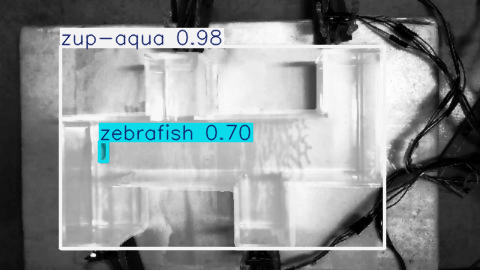

In [ ]:
import glob
import os
import random
import cv2
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# --- CONFIGURAÇÃO CORRIGIDA ---

# 1. Caminho do Modelo (Seu melhor modelo salvo no Drive - treino_IS2)
model_path = f'{HOME}/runs/treino_IS2/weights/best.pt'

# 2. Caminho das Imagens (O dataset de ZebraFish que você usou no treino)
# Usamos a variável 'dataset.location' para garantir que pegamos a pasta certa
images_dir = f'{dataset.location}/test/images'

print(f"📍 Buscando imagens em: {images_dir}")
print(f"🧠 Carregando modelo de: {model_path}\n")

# --- EXECUÇÃO ---

# 1. Busca imagens .jpg na pasta correta
files = glob.glob(f'{images_dir}/*.jpg')

if len(files) == 0:
    print(f"❌ Nenhuma imagem encontrada na pasta: {images_dir}")
    print("Verifique se a variável 'dataset.location' está definida corretamente.")
else:
    # 2. Sorteia uma imagem aleatória
    chosen_file = random.choice(files)
    print(f"🎲 Imagem sorteada: {os.path.basename(chosen_file)}")

    # 3. Carrega o modelo
    model = YOLO(model_path)

    # 4. Faz a predição
    # conf=0.25 é um bom ponto de partida. Se não detectar nada, tente baixar para 0.10
    results = model.predict(chosen_file, conf=0.25)
    result = results[0]

    # 5. Prepara a visualização
    # O .plot() desenha as caixas e as máscaras (segmentação)
    im_array = result.plot()

    # Converte de BGR (OpenCV) para RGB (Matplotlib/PIL) para as cores ficarem certas na tela
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    # Exibe a imagem final
    display(Image.fromarray(im_rgb))

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

🎨 Visualizando com Supervision: 2025-12-10-12-20-21-Cam-2_mp4-0511_jpg.rf.7efabbbc32f1bb71e1ca6766d00cb7ee.jpg

0: 384x640 2 aquas, 2 zebrafishs, 11.4ms
Speed: 1.7ms preprocess, 11.4ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


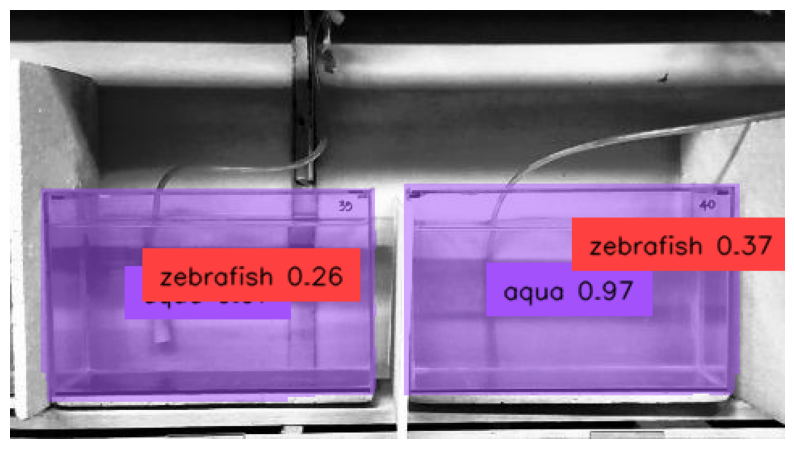

In [ ]:
import supervision as sv
import cv2
import glob
import random
import os
from ultralytics import YOLO

# --- CONFIGURAÇÃO ---
model_path = f'{HOME}/runs/treino_IS2/weights/best.pt'
images_dir = f'{dataset.location}/test/images'

# 1. Sorteio da Imagem
files = glob.glob(f'{images_dir}/*.jpg')
if not files:
    raise FileNotFoundError("Nenhuma imagem encontrada. Verifique os caminhos.")

chosen_file = random.choice(files)
print(f"🎨 Visualizando com Supervision: {os.path.basename(chosen_file)}")

# 2. Carregar Imagem e Modelo
# O Supervision trabalha nativamente com OpenCV (cv2)
image = cv2.imread(chosen_file)
model = YOLO(model_path)

# 3. Inferência
result = model(image)[0]

# --- A PONTE (Crucial) ---
# Convertemos o resultado do YOLO para o formato do Supervision
detections = sv.Detections.from_ultralytics(result)

# 4. Gerar Labels Personalizados
# O LabelAnnotator precisa de uma lista de strings para saber o que escrever
labels = [
    f"{model.names[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

# --- SEU CÓDIGO DE VISUALIZAÇÃO ---
# (Fiz pequenos ajustes para garantir que funcione na versão atual)

# Inicializa os anotadores
mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator(
    text_color=sv.Color.BLACK,
    text_position=sv.Position.CENTER, # Texto no meio do peixe
    text_scale=0.5
)

# Cria a cópia para desenhar
annotated_image = image.copy()

# Aplica as anotações
annotated_image = mask_annotator.annotate(
    scene=annotated_image,
    detections=detections
)

annotated_image = label_annotator.annotate(
    scene=annotated_image,
    detections=detections,
    labels=labels # Passamos os nomes das classes aqui
)

# 5. Exibe o resultado final
sv.plot_image(annotated_image, size=(10, 10))

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/segment/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [ ]:
project.version(dataset.version).deploy(
    model_type="yolov11-seg",
    model_path=f"{HOME}/runs/treino_IS2/"
)

View the status of your deployment at: https://app.roboflow.com/zebrarecog/zebrafish-detection-2-flcpc/5
Share your model with the world at: https://universe.roboflow.com/zebrarecog/zebrafish-detection-2-flcpc/model/5


In [ ]:
!pip install inference

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 45.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 80.7

☁️ Conectando ao modelo na nuvem: zebrafish-detection-2-flcpc/5


Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
Your `inference` configuration does not support SAM2 model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM2_ENABLED to False.
Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
Importing from timm.models.layers is deprecated, please import via timm.layers


[12/20/25 06:59:07] WARNING  Unsupported resize method 'Fit within', defaulting to 'Fit (black      ]8;id=905564;file:///usr/local/lib/python3.12/dist-packages/inference/core/models/roboflow.py\roboflow.py]8;;\:]8;id=958472;file:///usr/local/lib/python3.12/dist-packages/inference/core/models/roboflow.py#460\460]8;;\
                             edges) in' - this may result in degraded model performance.                           

Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
Specified provider 'CoreMLExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'



⚡ Processando via API Roboflow: ComCom_cobaia_2-converted_mp4-0055_jpg.rf.928ae4df118a4d2d4276804d5fb05c7d.jpg


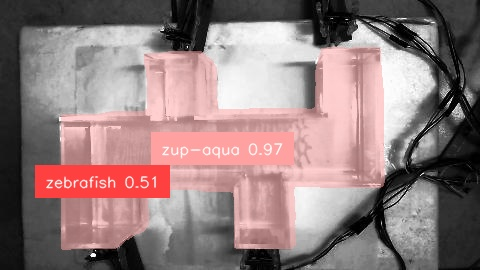


⚡ Processando via API Roboflow: WIN_20250818_17_04_29_Pro_frame_00090_jpg.rf.2adfcc60afff52921c39e053b9f701fa.jpg


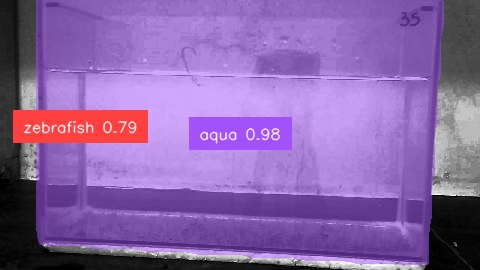


⚡ Processando via API Roboflow: ComSem_cobaia_1-converted_mp4-0066_jpg.rf.f2079020d1d07259779e8478fe8efcad.jpg


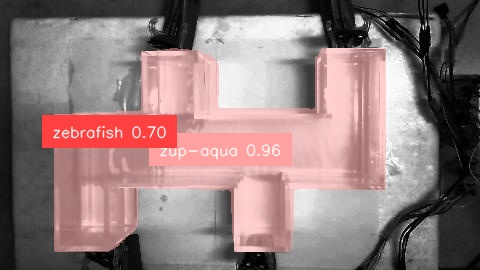

In [ ]:
import os
import random
import cv2
import supervision as sv
import IPython
import inference
from google.colab import userdata # <--- Essencial para ler sua API Key

# 1. Configuração do ID do Modelo e API Key
# O split garante que pegamos "workspace/project/version" corretamente
model_id = f"{project.id.split('/')[1]}/{dataset.version}"
api_key = userdata.get('ROBOFLOW_API_KEY')

print(f"☁️ Conectando ao modelo na nuvem: {model_id}")
model = inference.get_model(model_id, api_key)

# 2. Localização das imagens de teste
test_set_loc = dataset.location + "/test/images/"
test_images = [f for f in os.listdir(test_set_loc) if f.endswith('.jpg')]

# 3. Executar inferência em amostras aleatórias
# Aumentei para min(3, ...) para garantir que rode mesmo se tiver poucas imagens
sample_images = random.sample(test_images, min(3, len(test_images)))

for img_name in sample_images:
    print(f"\n⚡ Processando via API Roboflow: {img_name}")

    # Carregar imagem
    image_path = os.path.join(test_set_loc, img_name)
    image = cv2.imread(image_path)

    # Perform inference (Envia para a API ou roda localmente se o docker estiver ativo)
    results = model.infer(image)[0]

    # Converter para Supervision
    detections = sv.Detections.from_inference(results)

    # --- MELHORIA: Labels Personalizados ---
    # Isso garante que apareça "Zebrafish 0.95" e não apenas um quadrado vazio
    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence
        in zip(detections['class_name'], detections.confidence)
    ]

    # Anotar caixas e máscaras
    mask_annotator = sv.MaskAnnotator()
    label_annotator = sv.LabelAnnotator(text_position=sv.Position.CENTER, text_scale=0.5)

    annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)
    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
        labels=labels # <--- Passando os labels gerados
    )

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.